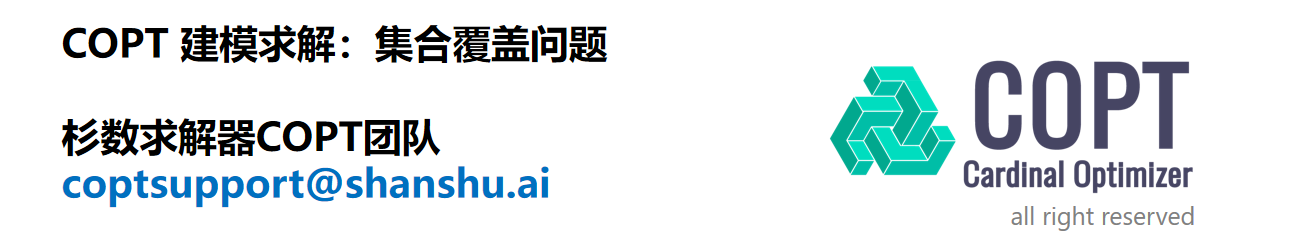

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


# 集合覆盖问题代码实现
## 使用COPT建模求解集合覆盖问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
    - 导入参数列表（包括各类媒体的费用、覆盖的人群类型等）

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $x_i$：二进制变量，表示是否选择第 $i$ 家媒体进行合作
    - **目标函数**：最小化总费用；
    - **约束条件**：
        - 每一种人群类型都要被至少一家媒体覆盖

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

## 添加模型数据

In [6]:
# 导入媒体成本信息
c = [20000, 50000, 60000, 45000, 30000, 55000, 60000, 52500]
# 导入媒体覆盖的人群类型
cover = [[1, 0, 0, 1, 0, 0],
         [0, 1, 1, 0, 0, 0],
         [0, 1, 0, 0, 0, 1],
         [1, 0, 0, 0, 0, 1],
         [0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 1],
         [0, 1, 0, 0, 1, 0],
         [1, 0, 0, 0, 1, 0]]
# 获取人数信息
num_type = len(cover[0])
num_media = len(cover)

## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
在本案例中，需要决定选择哪些媒体组合，故为每一家媒体添加一个二进制决策变量：

$$
    x_i = \begin{cases}
        1, & \text{选择了媒体} i \\
        0, & \text{没有选择媒体} i
    \end{cases}
$$

In [10]:
x = model_1.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

### 设置目标函数
最小化选择媒体的总成本：
$$
    \min \sum_{i} c_i \cdot x_i
$$

In [12]:
model_1.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MINIMIZE)

### 添加约束条件
每一种人群至少被一家媒体覆盖：
$$
    \sum_{i} cover_{ij} \cdot x_i \geq 1, \forall j = 0, 1, \cdots, num_{type} - 1
$$

In [14]:
model_1.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) >= 1 for j in range(num_type))

## 求解

In [16]:
model_1.solve()

Model fingerprint: 162a14cf

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    6 rows, 8 columns and 15 non-zero elements
    8 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    5 rows, 7 columns and 13 non-zero elements
    7 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [2e+04,6e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.000000e+04            --     Inf  0.05s
H        0         1      --       0  3.00000

## 获取结果

In [18]:
media_dict = {
    0: "时尚杂志",
    1: "深夜电视",
    2: "黄金时段电视",
    3: "列车广告牌",
    4: "公交广告牌",
    5: "全国性报纸",
    6: "财经类报纸",
    7: "地方性报纸"
}

if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")


最优投放成本：155000 元

选中的媒体方案：
  - 媒体 0: 时尚杂志
  - 媒体 3: 列车广告牌
  - 媒体 4: 公交广告牌
  - 媒体 6: 财经类报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 2 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


## 案例拓展：加入各种逻辑约束的集合覆盖问题代码实现
1. 若列车广告牌或公交广告牌被选中，则深夜电视或黄金时段电视中至少选中一家。该逻辑关系对应媒体索引集合 {3,4} → {1,2}，其线性化建模形式如下：

$$
    x_1 + x_2 \ge x_3
$$

$$
    x_1 + x_2 \ge x_4
$$

In [20]:
# 添加约束
model_1.addConstr(x[1] + x[2] >= x[3])
model_1.addConstr(x[1] + x[2] >= x[4])

# 取消日志文件显示
model_1.setParam(COPT.Param.Logging, False)

# 求解
model_1.solve()

# 获得结果
if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：157500 元

选中的媒体方案：
  - 媒体 1: 深夜电视
  - 媒体 5: 全国性报纸
  - 媒体 7: 地方性报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 1 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


2. 深夜电视与黄金时段电视、列车广告牌与公交广告牌之间的双向依赖关系。该约束刻画了媒体集合 {1,2}（深夜电视、黄金时段电视）与 {3,4}（列车广告牌、公交广告牌）之间的双向依赖关系，其建模形式为：

$$
    x_1 + x_2 \ge x_3
$$

$$
    x_1 + x_2 \ge x_4
$$

$$
    x_3 + x_4 \ge x_1
$$

$$
    x_3 + x_4 \ge x_2
$$

In [22]:
# 添加约束
# model_1.addConstr(x[1] + x[2] >= x[3]) # 上一问已添加
# model_1.addConstr(x[1] + x[2] >= x[4]) # 上一问已添加
model_1.addConstr(x[3] + x[4] >= x[1])
model_1.addConstr(x[3] + x[4] >= x[2])

# 求解
model_1.solve()

# 获得结果
if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：162500 元

选中的媒体方案：
  - 媒体 0: 时尚杂志
  - 媒体 2: 黄金时段电视
  - 媒体 4: 公交广告牌
  - 媒体 7: 地方性报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 2 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


3. 若黄金时段电视被选中，则列车广告牌与公交广告牌均不能被选中。该排他性约束对应媒体索引关系 2 → ¬{3,4}，可表示为：

$$
    x_3 + x_4 \le 2 \cdot (1 - x_2)
$$

In [24]:
# 添加约束
model_1.addConstr(x[3] + x[4] <= 2 * (1 - x[2]))

# 求解
model_1.solve()

# 获得结果
if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：167500 元

选中的媒体方案：
  - 媒体 0: 时尚杂志
  - 媒体 1: 深夜电视
  - 媒体 3: 列车广告牌
  - 媒体 7: 地方性报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 3 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


4. 若时尚杂志与深夜电视均被选中，则财经报纸也必须被选中。该蕴含关系对应媒体索引集合 {0,1} → 6，其线性化建模形式为：

$$
    x_6 \ge x_0 + x_1 - 1
$$

In [26]:
# 添加约束
model_1.addConstr(x[6] >= x[0] + x[1] - 1)

# 求解
model_1.solve()

# 获得结果
if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：175000 元

选中的媒体方案：
  - 媒体 0: 时尚杂志
  - 媒体 1: 深夜电视
  - 媒体 3: 列车广告牌
  - 媒体 6: 财经类报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 2 次
  - 人群类型 1: 被覆盖 2 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


5. 至少有三类目标人群被至少两家不同的媒体覆盖。为刻画该覆盖强度约束，引入辅助二进制变量 $y_j$，其建模形式如下：

$$
    \sum_{j = 0}^{|\mathcal{T}| - 1} y_j \ge 3
$$

$$
    2 \cdot y_j \le \sum_{i = 0}^{|\mathcal{M}| - 1} cover_{ij} \cdot x_i, \quad j = 0, 1, \ldots, |\mathcal{T}| - 1
$$

其中，辅助变量 $y_j$ 的定义为：

$$
    y_j = \begin{cases}
        1, & \text{若人群类型 } j \text{ 被至少两家媒体覆盖} \\
        0, & \text{否则}
    \end{cases}
$$

In [28]:
# 先加入新决策变量
y = model_1.addVars(num_type, vtype=COPT.BINARY, nameprefix='y')

# 加入一般约束
model_1.addConstr(cp.quicksum(y[j] for j in range(num_type)) >= 3)

<coptpy.Constraint: >

> 我们使用 `Model.addGenConstrIndicator()` 来设置指示器函数约束，首先，需要将原约束重写：
$$
    y_j = \begin{cases}
        1, & \sum_i cover_{ij} \cdot x_i >= 2 \\
        0, & \sum_i cover_{ij} \cdot x_i < 2 \\
    \end{cases}
    , \forall j = 0, 1, \cdots, num_{type} - 1 \\
$$

In [30]:
for j in range(num_type):
    model_1.addGenConstrIndicator(y[j], True, cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) >= 2, type=COPT.INDICATOR_IFANDONLYIF)

<font color=#B9C78D>
<b>提示：COPT指示器函数</b>
</font>   

在这里，我们采用的是COPT中的一种约束添加方式，即指示器函数。其本质是通过引入一个辅助二进制变量来表示某些逻辑条件的成立与否，从而将复杂的逻辑约束转化为线性或可处理的数学形式。这种方法实际上是大M法的一种实现，它通过引入一个足够大的常数M，将原本非线性的约束条件转化为具有明确不等式形式的线性约束，便于求解器进行处理和优化。

In [32]:
# 求解
model_1.solve()

# 获得结果
if model_1.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_1.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")


最优投放成本：205000 元

选中的媒体方案：
  - 媒体 0: 时尚杂志
  - 媒体 1: 深夜电视
  - 媒体 3: 列车广告牌
  - 媒体 4: 公交广告牌
  - 媒体 6: 财经类报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 2 次
  - 人群类型 1: 被覆盖 2 次
  - 人群类型 2: 被覆盖 2 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


从求解结果可以看到，随着约束条件的逐步增加，模型的最优目标函数值整体呈增加趋势。这是因为新增约束会限制部分原本可行且成本较低的解，使模型只能在更小的可行解空间内进行优化，从而需要选择成本更高的媒体组合。

## 案例拓展：集合覆盖问题的变种
### 集合划分问题
集合划分问题可视为集合覆盖问题的一种特殊形式，其主要差异在于对覆盖次数的要求更加严格。在集合覆盖问题中，每一类目标元素只需被至少一个子集覆盖；而在集合划分问题中，则进一步要求每个元素**恰好被一个子集覆盖一次**。

因此，其覆盖约束由“不少于一次”调整为“恰好一次”，对应的约束条件为：

$$
    \sum_{i \in \mathcal{M}} cover_{ij} \cdot x_i = 1,
    \quad j = 0, 1, \ldots, |\mathcal{T}| - 1
$$

In [35]:
# 创建求解模型
model_2 = env.createModel()

# 添加模型三要素
# 添加决策变量
x = model_2.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

# 设置目标函数
model_2.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MINIMIZE)

# 添加约束条件，注意这里发生改变
model_2.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) == 1 for j in range(num_type))

# 取消日志文件显示
model_2.setParam(COPT.Param.Logging, False)

# 求解
model_2.solve()

# 获得结果
if model_2.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_2.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：157500 元

选中的媒体方案：
  - 媒体 1: 深夜电视
  - 媒体 5: 全国性报纸
  - 媒体 7: 地方性报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 1 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次


### 集合包装问题

与集合划分问题相比，集合包装问题在建模形式上与原集合覆盖问题的差异更为显著。该问题不再关注“是否覆盖所有元素”，而是强调在不发生冲突的前提下，从多个候选集合中选择尽可能有价值的子集。在该模型中，目标函数由最小化总成本转变为**最大化所选子集的权重总和**；同时，覆盖约束由“至少覆盖一次”调整为“至多覆盖一次”，以避免同一元素被多个子集重复选择。

其数学模型可表示为：

$$
\begin{aligned}
    \max \quad 
    & \sum_{i \in \mathcal{M}} c_i \cdot x_i \\
    \text{s.t.} \quad 
    & \sum_{i \in \mathcal{M}} cover_{ij} \cdot x_i \le 1,
    \quad j = 0, 1, \ldots, |\mathcal{T}| - 1, \\
    & x_i \in \{0, 1\},
    \quad i = 0, 1, \ldots, |\mathcal{M}| - 1.
\end{aligned}
$$


In [37]:
# 创建求解模型
model_3 = env.createModel()

# 添加模型三要素
# 添加决策变量
x = model_3.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

# 设置目标函数
model_3.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MAXIMIZE)

# 添加约束条件，注意这里发生改变
model_3.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) <= 1 for j in range(num_type))

# 取消日志文件显示
model_3.setParam(COPT.Param.Logging, False)

# 求解
model_3.solve()

# 获取结果
if model_3.status == COPT.OPTIMAL:
    print(f"最优投放成本：{model_3.objVal:.0f} 元\n")

    # 选中的媒体索引
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print("选中的媒体方案：")
    for i in selected_media:
        print(f"  - 媒体 {i}: {media_dict[i]}")

    # 计算各类人群的覆盖次数
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\n各类目标人群的覆盖情况：")
    for j in range(num_type):
        print(f"  - 人群类型 {j}: 被覆盖 {covered[j]} 次")

else:
    print("模型未找到最优解")

最优投放成本：157500 元

选中的媒体方案：
  - 媒体 1: 深夜电视
  - 媒体 5: 全国性报纸
  - 媒体 7: 地方性报纸

各类目标人群的覆盖情况：
  - 人群类型 0: 被覆盖 1 次
  - 人群类型 1: 被覆盖 1 次
  - 人群类型 2: 被覆盖 1 次
  - 人群类型 3: 被覆盖 1 次
  - 人群类型 4: 被覆盖 1 次
  - 人群类型 5: 被覆盖 1 次
